# Cy5 Cis model ($tS_0, tS_1, tT_1, Cis, B$)
This model comprises the ground state $S_0$, the excited singlet state $S_1$, the excited triplet state $T_1$ in the fluoroscent trans form (indicated by the 't'), the non-fluorescent cis state, as well as the bleached state $B$.

In [2]:
#user = r"\SagixOffice"  # HomeOffice
user = r"\vie43sq"  # University
import sys
sys.path.append(rf"C:\Users{user}\OneDrive - Universität Würzburg\GitHub\Photoswitching")

import numpy as np
import matplotlib.pyplot as plt
import src.figures as fi
import src.custom_plot as cp
import src.fluorophore_systems as fs
from IPython.display import HTML

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


### Define the state transition rates

In [3]:
rate_dict = dict(k_tS0_tS1=[7e6, "excitation"],
                 k_tS1_tS0=[1e9, "emission"],
                 k_tS1_tT1=[1e6, "intersystem crossing"],
                 k_tT1_tS0=[5e5, "triplet deexcitation"],
                 
                 k_tS1_Cis=[2e7, "isomerization"],
                 k_Cis_tS0=[1e5, "backisomerization"])

### Initialize system

In [4]:
system = fs.Cy5CisModel(number=3, distances=1, rates=rate_dict)

### Simulate the Markov process

In [5]:
system.simulate(n_steps=10000000, seed=99)

In [6]:
system.process()

### State occupation histograms and durations

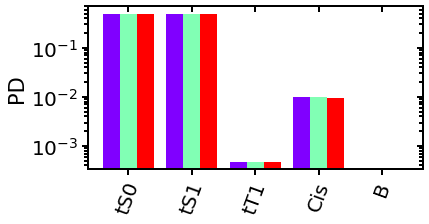

In [7]:
fig, ax = fi.FigureCollection(system).populations(mode="single_states", single_fluorophores=True,
                                                  bins=np.arange(0, 6)-0.5)
# shows all possible states of the system, even if not occupied, if bins parameter allows it

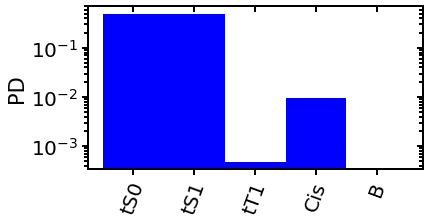

In [8]:
fig, ax = fi.FigureCollection(system).populations(mode="single_states", single_fluorophores=False, 
                                                  bins=np.arange(0, 6)-0.5)
# shows all possible states of the system, even if not occupied, if bins parameter allows it

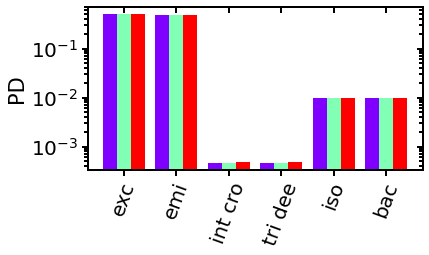

In [9]:
fig, ax = fi.FigureCollection(system).populations(mode="transitions", single_fluorophores=True,
                                                  bins=np.arange(0, 7)-0.5)
# shows all possible transitions of the system, even if they didn't happen, if bins parameter 
# allows it

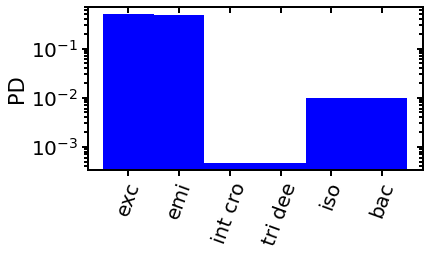

In [10]:
fig, ax = fi.FigureCollection(system).populations(mode="transitions", single_fluorophores=False,
                                                  bins=np.arange(0, 7)-0.5)
# shows all possible transitions of the system, even if they didn't happen, if bins parameter
# allows it

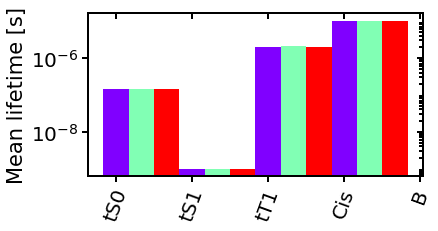

In [11]:
fig, ax = fi.FigureCollection(system).lifetimes(mode="single_states", statistic="mean",
                                                single_fluorophores=True)
# cuts out states that have no lifetime (absorbing or unoccupied states) from right to left

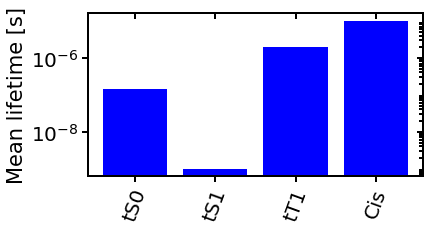

In [12]:
fig, ax = fi.FigureCollection(system).lifetimes(mode="single_states", statistic="mean",
                                                single_fluorophores=False)
# cuts out states that have no lifetime (absorbing or unoccupied states) from right to left

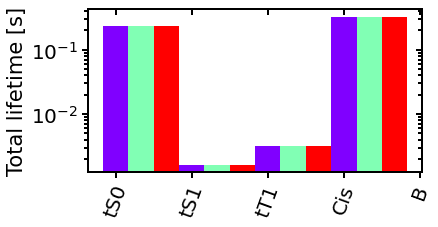

In [13]:
fig, ax = fi.FigureCollection(system).lifetimes(mode="single_states", statistic="total",
                                                single_fluorophores=True)
# cuts out states that have no lifetime (absorbing or unoccupied states) from right to left

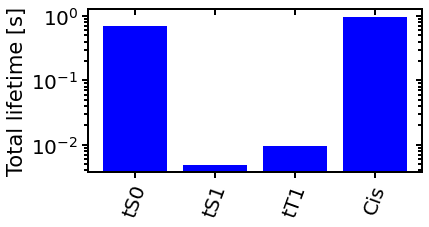

In [14]:
fig, ax = fi.FigureCollection(system).lifetimes(mode="single_states", statistic="total",
                                                single_fluorophores=False)
# cuts out states that have no lifetime (absorbing or unoccupied states) from right to left

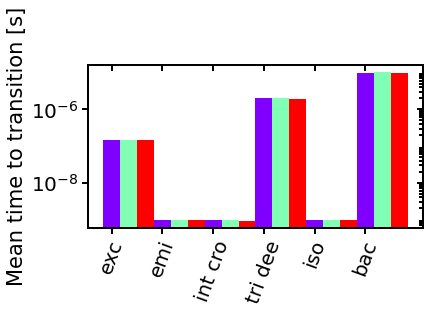

In [15]:
fig, ax = fi.FigureCollection(system).lifetimes(mode="transitions",
                                                single_fluorophores=True)
# cuts out transitions that didn't occur from right to left

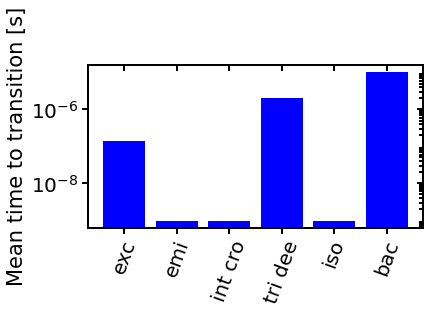

In [16]:
fig, ax = fi.FigureCollection(system).lifetimes(mode="transitions",
                                                single_fluorophores=False)
# cuts out transitions that didn't occur from right to left

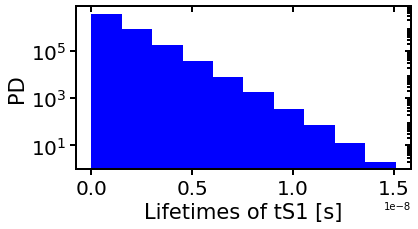

In [17]:
fig, ax = fi.FigureCollection(system).individual_lifetimes(fluorophore_id=0, 
                                                           single_state_id=1)

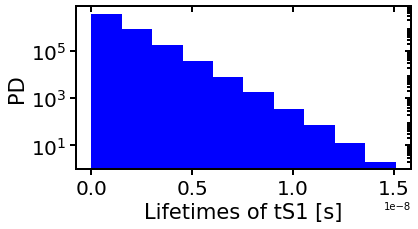

In [18]:
fig, ax = fi.FigureCollection(system).individual_lifetimes(fluorophore_id=None,
                                                           single_state_id=1)

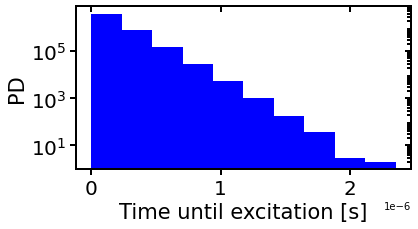

In [19]:
fig, ax = fi.FigureCollection(system).individual_lifetimes(fluorophore_id=None,
                                                           transition_id=0)

### Emission analysis
Depends largely on the resample parameter in method 'emitters'. Do not forget to adjust the axis labels accordingly (see ON/OFF plots).

In [20]:
system.emitters(photon_collection=1, resample="0.1us", unit="s", emccd_gain=100,
                threshold=0, memory=0, use_unique=True, remove_heading_off_period=False, 
                seed=100)

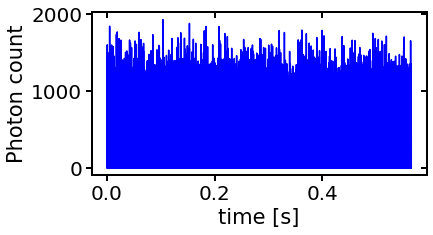

In [21]:
fig, ax = fi.FigureCollection(system).emission_events(time_series=True)

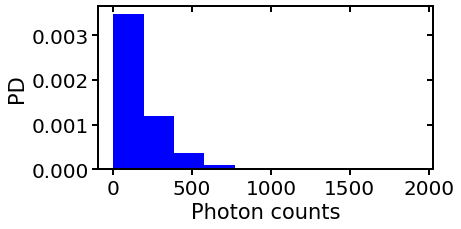

In [22]:
fig, ax = fi.FigureCollection(system).emission_events(time_series=False,
                                                      pois=False)

#### Fluorescence correlation spectroscopy

In [23]:
system.fcs(normalize=True, log=True, m=2, deltat=5e-7)

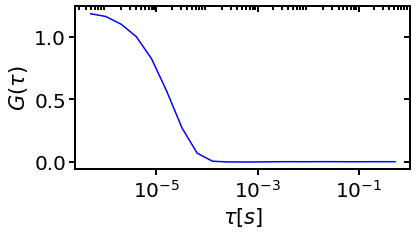

In [24]:
fig, ax = fi.FigureCollection(system).fcs(log=True, normalize_to=4)

#### ON periods and OFF periods
An ON period is a number of consecutive frames where each frame contains a minimum amount of emissions ($>$ threshold). 
An OFF period is a number of consecutive frames where each frame contains a maximum amount of emissions ($\le$ threshold).

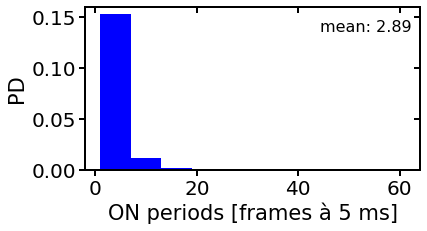

In [25]:
fig, ax = fi.FigureCollection(system).on_off(mode="on", time_series=False, resample="5 ms",
                                             display_mean=True)

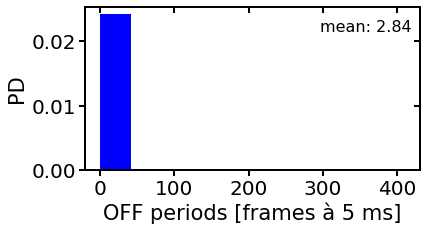

In [26]:
fig, ax = fi.FigureCollection(system).on_off(mode="off", time_series=False, resample="5 ms",
                                             display_mean=True)

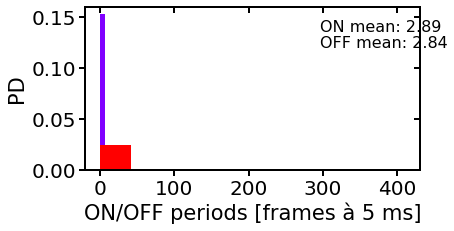

In [27]:
fig, ax = fi.FigureCollection(system).on_off(mode="mesh", time_series=False, resample="5 ms",
                                             display_mean=True)

#### Time series of ON and OFF periods
Displays all ON (or OFF) periods consecutively with their number of frames. Note that each ON period is followed by an OFF period and vice versa.

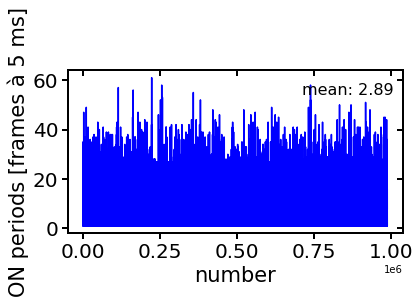

In [28]:
fig, ax = fi.FigureCollection(system).on_off(mode="on", time_series=True, resample="5 ms",
                                             display_mean=True)

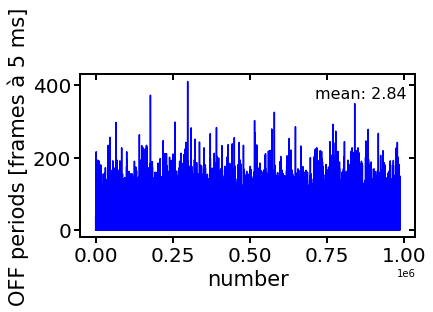

In [29]:
fig, ax = fi.FigureCollection(system).on_off(mode="off", time_series=True, resample="5 ms",
                                             display_mean=True)

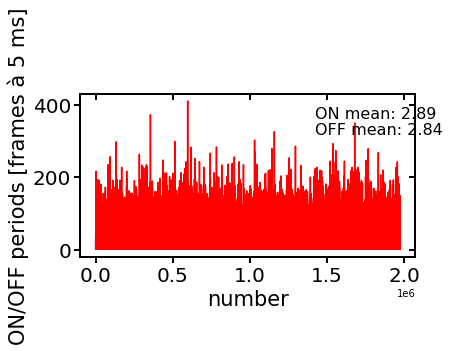

In [30]:
fig, ax = fi.FigureCollection(system).on_off(mode="mesh", time_series=True, resample="5 ms")